In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
# import cospar
import scanpy as sc
import pseudodynamics as pdp
import numpy as np
import pandas as pd

import palantir
from pseudodynamics import tl

import seaborn as sns
import matplotlib.pyplot as plt

/local/scratch/wz369/PINN_env/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/local/scratch/wz369/PINN_env/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Ann

In [3]:
# pdp.main_dir = "/rds/user/wz369/hpc-work/PINN_dynamics"

In [4]:
os.chdir(pdp.main_dir)
sc.set_figure_params(dpi=80, frameon=False)

In [5]:
pop_ad = sc.read_h5ad("data/klein_addpop.h5ad")
pop_ad

AnnData object with n_obs × n_vars = 126861 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'palantir_pseudotime', 'palantir_entropy', 'split', 'bifate_mask'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'iroot', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'root_cb', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_diffmap', 'X_pca', 'X_pca_scaled', 'X_umap', 'delta_DM', 'delta_PC', 'guassian_kde_u_DM_EigenVectors', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connect

# split 

In [6]:
test_ad = pop_ad[pop_ad.obs.Well == 2].copy()
trainval_ad = pop_ad[pop_ad.obs.Well != 2].copy()

In [ ]:
# tuc : test unique clones
test_unique_clone = ~test_ad.obs.clones.isin(trainval_ad.obs.clones.cat.categories)
tuc_ad = test_ad[test_unique_clone]

<Axes: ylabel='Frequency'>

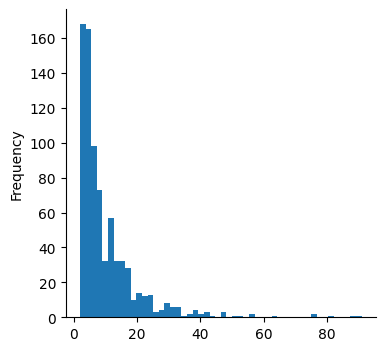

In [ ]:
clone_time_counts = tuc_ad.obs[['clones','time_cat']].groupby('clones').agg({'time_cat':['nunique','count']})['time_cat']
clone_time_counts.query("nunique==2")['count'].plot(kind='hist', bins=50)

In [44]:
# vtc 
valid_test_clones = clone_time_counts.query("nunique==2 & `count` >= 20").index
vtc_mask = test_ad.obs.clones.isin(valid_test_clones)
vtc_ad = test_ad[vtc_mask].copy()
vtc_ad

AnnData object with n_obs × n_vars = 3030 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'palantir_pseudotime', 'palantir_entropy', 'split'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'iroot', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'root_cb', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_diffmap', 'X_pca', 'X_umap', 'delta_DM', 'delta_PC', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [48]:
print(len(valid_test_clones))

92


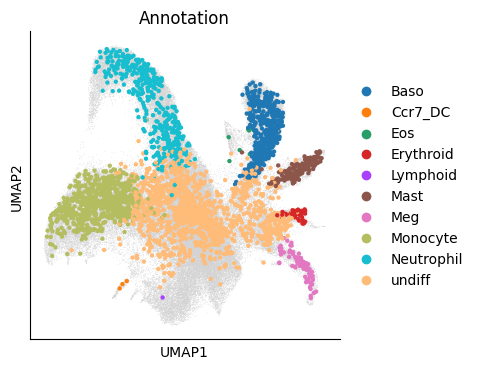

In [49]:
fig = sc.pl.umap(pop_ad, return_fig=True, show=False)
sc.pl.umap(vtc_ad, color='Annotation', ax=fig.gca())

In [50]:
vtc_ad.obs


,Time_point,Population,Annotation,Well,time_cat,leiden,comb,label_man,clones,Meta clones,group,timepoint_tx_days,selected_clonal_cells,palantir_pseudotime,palantir_entropy,split
1,6.0,LK,undiff,2,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_1440,8,8,6.0,True,0.361158,0.299648,test
4,6.0,LK,undiff,2,6.0,9,undiff_9,prog_Meg_Ery,Clone_1972,4,4,6.0,True,0.194444,0.970881,test
25,6.0,LK,undiff,2,6.0,8,undiff_8,prog_4,Clone_3438,0,0,6.0,True,0.087535,1.522936,test
27,6.0,LK,Baso,2,6.0,10,Baso_10,prog_Baso_Eos,Clone_1972,4,4,6.0,True,0.434556,0.057252,test
30,6.0,LK,Monocyte,2,6.0,13,Monocyte_13,prog_Mono,Clone_3887,0,0,6.0,True,0.217589,0.013774,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110859,4.0,LSK,undiff,2,4.0,0,undiff_0,prog_2,Clone_961,0,0,4.0,True,0.047268,1.312168,test
111090,4.0,LSK,undiff,2,4.0,6,undiff_6,prog_3,Clone_123,0,0,4.0,True,0.041763,1.308622,test
111094,4.0,LSK,undiff,2,4.0,0,undiff_0,prog_2,Clone_3083,0,0,4.0,True,0.040123,1.309924,test
111360,4.0,LSK,Mast,2,4.0,17,Mast_17,Mast,Clone_17,10,10,4.0,True,0.681666,0.008191,test


In [52]:
# Create a contingency table of clones vs cell types
contingency_table = pd.crosstab(vtc_ad.obs['clones'], vtc_ad.obs['Annotation'])

# Calculate proportions within each clone (row-wise)
clone_proportions = contingency_table.div(contingency_table.sum(axis=1), axis=0)
    

In [54]:
clone_proportions

Annotation,Baso,Ccr7_DC,Eos,Erythroid,Lymphoid,Mast,Meg,Monocyte,Neutrophil,undiff
clones,,,,,,,,,,
Clone_17,0.00000,0.0,0.0,0.000,0.0,1.00,0.000000,0.000000,0.000000,0.000000
Clone_123,0.24000,0.0,0.0,0.000,0.0,0.00,0.000000,0.440000,0.000000,0.320000
Clone_358,0.00000,0.0,0.0,0.000,0.0,0.00,0.000000,0.000000,0.000000,1.000000
Clone_374,0.00000,0.0,0.0,0.000,0.0,0.00,0.000000,0.000000,0.760000,0.240000
Clone_398,0.00000,0.0,0.0,0.000,0.0,0.00,0.407407,0.000000,0.037037,0.555556
...,...,...,...,...,...,...,...,...,...,...
Clone_5717,0.00000,0.0,0.0,0.025,0.0,0.75,0.000000,0.000000,0.000000,0.225000
Clone_5748,0.00000,0.0,0.0,0.000,0.0,0.00,0.000000,0.000000,0.000000,1.000000
Clone_5791,0.47619,0.0,0.0,0.000,0.0,0.00,0.000000,0.071429,0.142857,0.309524


In [9]:
clone_proportions = clone_proportions.query("`undiff` < 0.2")

In [56]:
clone_proportions.to_csv('data/klein/clone_proportions.csv', index=True)

# resume

In [7]:
clone_proportions = pd.read_csv('data/klein/clone_proportions.csv', index_col=0)

In [8]:
print(clone_proportions.index.shape)

(92,)


In [23]:
w2_clone_mask = test_ad.obs.clones.isin(clone_proportions.index)
w2_test_ad = test_ad[w2_clone_mask].copy()
w2_test_ad

AnnData object with n_obs × n_vars = 3030 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'palantir_pseudotime', 'palantir_entropy', 'split', 'bifate_mask'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'iroot', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'root_cb', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_diffmap', 'X_pca', 'X_pca_scaled', 'X_umap', 'delta_DM', 'delta_PC', 'guassian_kde_u_DM_EigenVectors', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectiv

In [25]:
# start cell
w2_test_ad[w2_test_ad.obs.timepoint_tx_days == 4]

View of AnnData object with n_obs × n_vars = 737 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'palantir_pseudotime', 'palantir_entropy', 'split', 'bifate_mask'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'iroot', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'root_cb', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_diffmap', 'X_pca', 'X_pca_scaled', 'X_umap', 'delta_DM', 'delta_PC', 'guassian_kde_u_DM_EigenVectors', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'co

In [9]:
import sys
sys.path.append(os.path.join(pdp.main_dir, 'scripts'))
import fate_eval_pipeline as fate_eval
from torchcfm.optimal_transport import wasserstein

# test

In [13]:
pdp_main = "/home/wz369/rds/hpc-work/pseudodynamics_plus/"
config_path = os.path.join(pdp_main, "logs/klein_PC30_lD1_cfm2_lgNone/pde_params_tsense/V0_config.json")
PCcfm1_config = pdp.ExperimentConfig(config_path)

In [14]:
PCcfm1_config.from_json(config_path, main_dir=pdp_main)

In [15]:
PCcfm1_config.find_lastest_ckpt()

'/home/wz369/rds/hpc-work/pseudodynamics_plus/logs/klein_PC30_lD1_cfm2_lgNone/pde_params_tsense/lightning_logs/version_0/checkpoints/epoch=152-val_loss=11.58990479.ckpt'

In [16]:
sim_fn = fate_eval.make_pseudodynamics_sb_sim_fn(t_start_norm=2.0, t_end_norm=4.0, n_steps=100, noise_scale=0.5)

In [18]:
import torch
torch.cuda.is_available()

True

In [21]:
get_w2_v1(test_ad, clone_proportions, PCcfm1_config, "cuda:0", sim_fn)

RuntimeError: X1 and X2 must have the same number of columns. X1: 3000 X2: 30

In [33]:
config=PCcfm1_config
device='cuda:0'
n_sims=4

In [34]:
# get some data key
n_dims = config.dataset_config['n_dimension']
cellstate_key = config.dataset_config.get("cellstate_key", None)
timepoint_key = config.dataset_config.get("timepoint_key", "timepoint_tx_days")


# get start cell
w2_clone_mask = test_ad.obs.clones.isin(clone_proportions.index)
w2_test_ad = test_ad[w2_clone_mask].copy()
start_ad = w2_test_ad[w2_test_ad.obs.timepoint_tx_days == 4]
start_cells = start_ad.obsm[cellstate_key][:,:n_dims]

# ref : ground truth
ref_ad = w2_test_ad[w2_test_ad.obs.timepoint_tx_days == 6]
ref_cells = ref_ad.obsm[cellstate_key][:,:n_dims]

# load model
pde_model = pdp.models.pde_params.load_from_checkpoint(
config.find_lastest_ckpt()).to(device)

endpoints = np.asarray(sim_fn(start_cells, pde_model, n_sims, device))
endpoints = endpoints.reshape(-1, start_cells.shape[1])

In [35]:
endpoints = endpoints.reshape(-1, start_cells.shape[1])

In [36]:
w2 = wasserstein(
    torch.from_numpy(endpoints).to(device),
    torch.from_numpy(ref_cells).to(device),
    reg=0.05
)

In [41]:
klein_w2_v1(test_ad, clone_proportions, PCcfm1_config, 
            'cuda:0', sim_fn, n_sims=10)

6.425244695571498

In [42]:
klein_w2_v1(test_ad, clone_proportions, PCcfm1_config, 
            'cuda:0', sim_fn, n_sims=20)

6.410607966914718

In [40]:
def klein_w2_v1(test_ad:sc.AnnData, 
              clone_proportions:pd.DataFrame, 
              config:pdp.ExperimentConfig, 
              device:torch.device, 
              sim_fn:callable, 
              n_sims=10, 
              reg=0.05):
    R"""
    Compute W2 loss from t4 cells to t6 cells for testset specific clones
    """

    # get some data key
    n_dims = config.dataset_config['n_dimension']
    cellstate_key = config.dataset_config.get("cellstate_key", None)
    timepoint_key = config.dataset_config.get("timepoint_key", "timepoint_tx_days")


    # get start cell
    w2_clone_mask = test_ad.obs.clones.isin(clone_proportions.index)
    w2_test_ad = test_ad[w2_clone_mask].copy()
    start_ad = w2_test_ad[w2_test_ad.obs.timepoint_tx_days == 4]
    start_cells = start_ad.obsm[cellstate_key][:,:n_dims]

    # ref : ground truth
    ref_ad = w2_test_ad[w2_test_ad.obs.timepoint_tx_days == 6]
    ref_cells = ref_ad.obsm[cellstate_key][:,:n_dims]

    # load model
    pde_model = pdp.models.pde_params.load_from_checkpoint(
    config.find_lastest_ckpt()).to(device)

    endpoints = np.asarray(sim_fn(start_cells, pde_model, n_sims, device))
    endpoints = endpoints.reshape(-1, start_cells.shape[1])

    with torch.no_grad():
        w2 = wasserstein(
            torch.from_numpy(endpoints).to(device),
            torch.from_numpy(ref_cells).to(device),
            reg=reg
            )
    return w2